<a href="https://colab.research.google.com/github/Dungmeww/ThucHanh_DeepLearning/blob/Buoi4/CNN_bai1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

In [ ]:

mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print("Kích thước tập train ban đầu:", df_train.shape)
print("Kích thước tập test ban đầu:", df_test.shape)

Kích thước tập train ban đầu: (19999, 785)
Kích thước tập test ban đầu: (9999, 785)


In [ ]:
num_classes = 10
input_shape = (28, 28, 1)

# Separate features (X) and labels (y)
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]
X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]

# Convert to float32 and normalize
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Reshape for CNN input
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print("Shape of X_train:", X_train.shape)

X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print("Shape of X_test:", X_test.shape)

# Convert labels to one-hot encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print('Number of classes:', len(np.unique(df_train.iloc[:, 0])))
print('Classes:', np.unique(df_train.iloc[:, 0]))
print('First 5 one-hot encoded y_train labels:\n', y_train[:5])

Shape of X_train: (19999, 28, 28, 1)
Shape of X_test: (9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
First 5 one-hot encoded y_train labels:
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
model = Sequential(
    [
        Input(shape=input_shape),
        Conv2D(32, kernel_size=(3, 3), activation="relu"),
        MaxPool2D(pool_size=(2, 2)),
        Conv2D(64, kernel_size=(3, 3), activation="relu"),
        MaxPool2D(pool_size=(2, 2)),
        Flatten(),
        Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 10
batch_size = 128

history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test))

print("Training complete.")

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9910 - loss: 0.0280 - val_accuracy: 0.9819 - val_loss: 0.0605
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.9928 - loss: 0.0235 - val_accuracy: 0.9835 - val_loss: 0.0558
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9940 - loss: 0.0194 - val_accuracy: 0.9850 - val_loss: 0.0498
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.9946 - loss: 0.0177 - val_accuracy: 0.9835 - val_loss: 0.0544
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.9941 - loss: 0.0171 - val_accuracy: 0.9824 - val_loss: 0.0639
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.9964 - loss: 0.0124 - val_accuracy: 0.9834 - val_loss: 0.0636
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.9969 - loss: 0.0110 - val_accuracy: 0.9824 - val_loss: 0.0695
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.9953 - loss: 0.0139 - va

In [ ]:
score = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.06762531399726868
Test accuracy: 0.9830983281135559


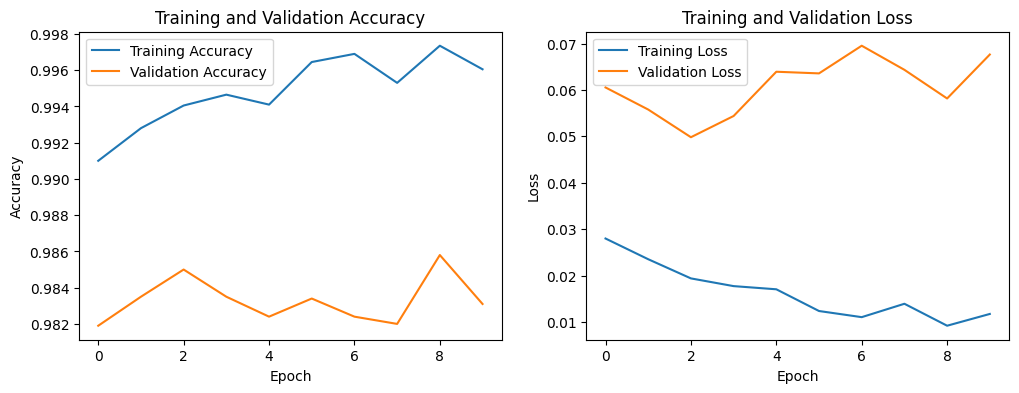

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


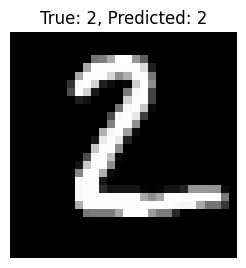

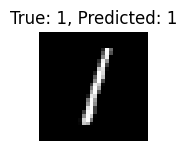

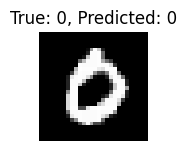

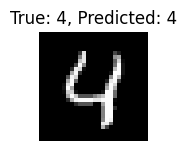

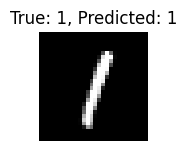

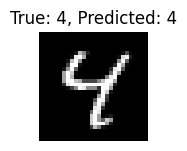

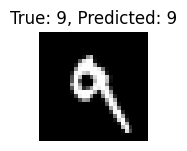

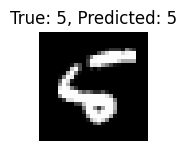

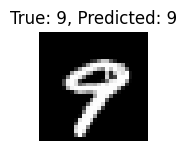

<Figure size 640x480 with 0 Axes>

In [ ]:
predictions = model.predict(X_test)

def plot_prediction(index):
    plt.imshow(X_test[index].reshape(28, 28), cmap='gray')
    plt.title(f"True: {np.argmax(y_test[index])}, Predicted: {np.argmax(predictions[index])}")
    plt.axis('off')
    plt.show()

# Display a few predictions
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plot_prediction(i)
plt.tight_layout()
plt.show()